In [50]:
# Import packages
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [51]:
# FUNCTION INITIALISATION

## LORENZ SYSTEM 
def lorenz(x, y, z, sigma, rho, beta):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = (x * y) - (beta * z)
    return([dx, dy, dz])

def calc_lorenz(steps):
    rx = r[0][0]; ry = r[0][1]; rz = r[0][2]
    
    h = 0.01
    t = 0
    for i in range(1,steps):
        t += h

        k1 = lorenz(rx, ry, rz, sigma, rho, beta)
        k2 = lorenz(rx + h*0.5*k1[0], ry + h*0.5*k1[1], rz + h*0.5*k1[2], sigma, rho, beta)
        k3 = lorenz(rx + h*0.5*k2[0], ry + h*0.5*k2[1], rz + h*0.5*k2[2], sigma, rho, beta)
        k4 = lorenz(rx + h*k3[0], ry + h*k3[1], rz + h*k3[2], sigma, rho, beta)

        rx += h/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        ry += h/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        rz += h/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])

        r.append([rx, ry, rz])
    
    return np.array(r)


# Reservoir Computing functions:
def spectral_radius(A): # returns the spectral radius of a matrix
    eigenvalues = np.linalg.eigvals(A)
    return(max(abs(eigenvalues)))

def normalisation(A): # Normalises a given matrix 
    s = spectral_radius(A)
    if (s == 0):
        print("Error: spectral radius = 0. Unable to normalise.")
        return
    else:
        return(1/s * A)

def rescale(A, alpha): # Rescale matrix to given a target spectral radius.
                       # choose alpha w.r.t dynamics. small values for faster dynamics, large values for slower dynamics.
    return(alpha * A)

def generate_DR(gen_seed): # Generates the W and W_in matrices (with a given seed if applicable)
    if(gen_seed == 0):
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(gen_seed)
    W0 = rng.uniform(-1, 1, size = (N,N))
    W1 = normalisation(W0)
    W = rescale(W1, target_radius)
    
    W_in = rng.uniform(-0.12, 0.12, size = (N,3))
    return(W_in, W)


def train_esn(U, W, W_in, leak, washout=300, ridge=1e-3): # Trains the ESN
    T = U.shape[0]
    N = W.shape[0]
    
    x = np.zeros(N)
    X = []
    Y = []
    
    for n in range(T-1):
        x = (1-leak) * x + leak*np.tanh((W @ x) + (W_in @ U[n]))
        
        if n>= washout:
            z = np.hstack([1, x, U[n]])
            X.append(z)
            Y.append(U[n+1])
            
    X = np.array(X)
    Y = np.array(Y)
    
    I = np.eye(X.shape[1])
    I[0, 0] = 0
    W_out = np.linalg.solve((X.T @ X + ridge * I), X.T @ Y)
    return W_out

def predict_esn(U, W, W_in, W_out, leak, steps):
    N = W.shape[0]
    x = np.zeros(N)
    u = U.copy()

    preds = []
    preds.append(u)

    for n in range(steps-1):
        x = (1-leak)*x + leak*np.tanh(W @ x + W_in @ u)
        z = np.hstack([1, x, u])
        u = z @ W_out
        preds.append(u)

    return np.array(preds)

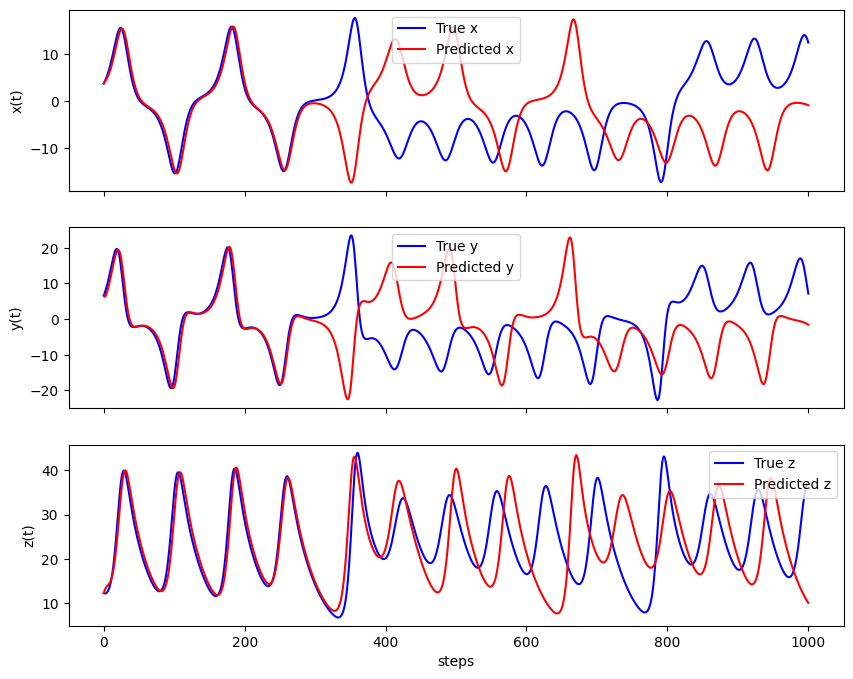

In [70]:
seed = 4 # Set a seed for reproducibility (set seed to 0 for random)
N = 500 # Number of internal reservoir nodes
leak = 0.4 
pred_steps = 1000 # Number of steps to predict
target_radius = 0.6 # Target reservoir spectral radius
r = [[4,5,6]] # Lorenz system initial conditons

# Lorenz parameters
sigma = 10
rho =  28
beta = 8/3

rx = r[0][0]; ry = r[0][1]; rz = r[0][2]
T = 2000 # Number of Lorenz system steps to store

x_pred = [0]
y_pred = [0]
z_pred = [0]

W_in, W = generate_DR(seed)

# standardise training set (optional)
data = calc_lorenz(T)
# mean = data.mean(axis=0)
# std  = data.std(axis=0) + 1e-12
# data = (data - mean) / std
U_train = data[:round(T*0.8):]
U_test = data[:round(T*0.2)]

# Train W_out weight matrix
W_out = train_esn(U_train, W, W_in, leak, pred_steps)

# Predict the next 500 steps in time series
u0 = data[-1]
pred = predict_esn(u0, W, W_in, W_out, leak, pred_steps)

# Calculate the true values for the next 500 steps
r = [[data[-1][0],data[-1][1],data[-1][2]]]
dx = 0; dy = 0; dz = 0
true_data = calc_lorenz(pred_steps)
x_true = [i[0] for i in true_data]
y_true = [i[1] for i in true_data]
z_true = [i[2] for i in true_data]

# PLOTS
# Setup data for plotting
x_pred = [i[0] for i in pred]
y_pred = [i[1] for i in pred]
z_pred = [i[2] for i in pred]
pred_range = np.linspace(0, pred_steps, pred_steps)

# Plot the predicted values against true values
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# x(t)
axes[0].plot(pred_range, x_true, label="True x", color="blue")
axes[0].plot(pred_range, x_pred, label="Predicted x", color="red")
axes[0].set_ylabel("x(t)")
axes[0].legend()

# y(t)
axes[1].plot(pred_range, y_true, label="True y", color="blue")
axes[1].plot(pred_range, y_pred, label="Predicted y", color="red")
axes[1].set_ylabel("y(t)")
axes[1].legend()

# z(t)
axes[2].plot(pred_range, z_true, label="True z", color="blue")
axes[2].plot(pred_range, z_pred, label="Predicted z", color="red")
axes[2].set_ylabel("z(t)")
axes[2].set_xlabel("steps")
axes[2].legend()

plt.savefig("lorenz_prediction.png")
plt.show()